# 1 Dataset Analysis

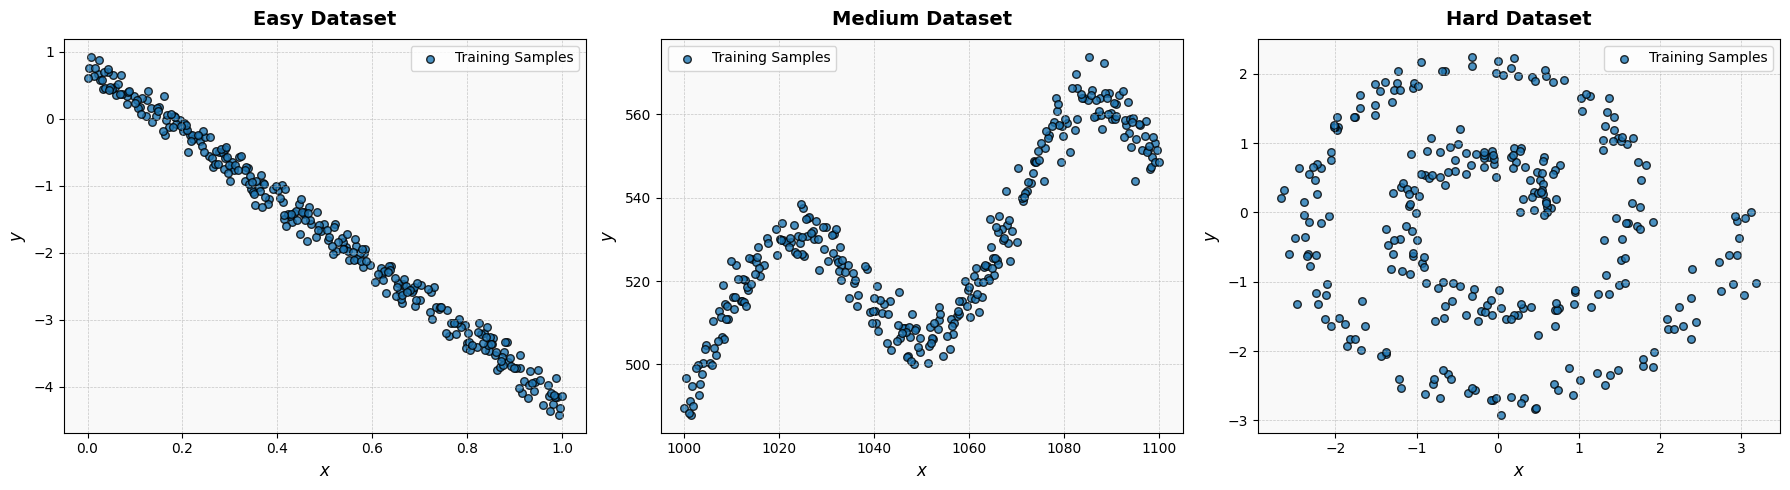

In [101]:
import numpy as np
import matplotlib.pyplot as plt

def load_dataset(train_path, test_path):
    train = np.loadtxt(train_path)
    test = np.loadtxt(test_path)
    x_train, y_train = train[:, 0], train[:, 1]
    x_test, y_test = test[:, 0], test[:, 1]
    return x_train, y_train, x_test, y_test

def plot_1d_dataset(x, y, title, ax):
    ax.scatter(x, y, color='tab:blue', alpha=0.8, s=30, edgecolor='k', label='Training Samples')
    ax.set_title(title, fontsize=14, weight='bold', pad=10)
    ax.set_xlabel(r"$x$", fontsize=12)
    ax.set_ylabel(r"$y$", fontsize=12)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.legend(loc='best', fontsize=10)
    ax.tick_params(axis='both', labelsize=10)
    ax.set_facecolor('#f9f9f9')

# Load datasets from data/ folder
easy_x, easy_y, _, _     = load_dataset("data/easy_train.txt", "data/easy_test.txt")
medium_x, medium_y, _, _ = load_dataset("data/medium_train.txt", "data/medium_test.txt")
hard_x, hard_y, _, _     = load_dataset("data/hard_train.txt", "data/hard_test.txt")

# Plot all three datasets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_1d_dataset(easy_x, easy_y, "Easy Dataset", axes[0])
plot_1d_dataset(medium_x, medium_y, "Medium Dataset", axes[1])
plot_1d_dataset(hard_x, hard_y, "Hard Dataset", axes[2])
plt.tight_layout()
plt.show()


# 2 Model Implementation

In [93]:
import numpy as np

# Activation functions and their derivatives
# gradient clippnig aswell
activation_functions = {
    'sigmoid': lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500))),
    'tanh': np.tanh,
    'relu': lambda x: np.maximum(0, x),
}

activation_derivatives = {
    'sigmoid': lambda x: activation_functions['sigmoid'](x) * (1 - activation_functions['sigmoid'](x)),
    'tanh': lambda x: 1 - np.tanh(x) ** 2,
    'relu': lambda x: (x > 0).astype(float),
}


# Single Layer Perceptron (SLP)
class SingleLayerPerceptron:
    def __init__(self, input_dim, learning_rate=0.01, momentum=0.0, weight_range=(-1, 1)):
        self.lr = learning_rate
        self.momentum = momentum
        low, high = weight_range
        self.w = np.random.uniform(low, high, size=(input_dim,))
        self.b = 0.0
        self.v_w = np.zeros_like(self.w)
        self.v_b = 0.0

    def predict(self, x):
        return np.dot(x, self.w) + self.b

    def _train_step(self, x_batch, y_batch):
        y_pred = self.predict(x_batch)
        error = y_pred - y_batch
        grad_w = (2 / len(x_batch)) * np.dot(x_batch.T, error)
        grad_b = (2 / len(x_batch)) * np.sum(error)

        if self.momentum > 0:
            self.v_w = self.momentum * self.v_w + (1 - self.momentum) * grad_w
            self.v_b = self.momentum * self.v_b + (1 - self.momentum) * grad_b
            self.w -= self.lr * self.v_w
            self.b -= self.lr * self.v_b
        else:
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

    def train(self, x, y, epochs=2000, batch_size=16, verbose=False):
        for epoch in range(epochs):
            indices = np.random.permutation(len(x))
            x_shuffled, y_shuffled = x[indices], y[indices]
            for i in range(0, len(x), batch_size):
                x_batch = x_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                self._train_step(x_batch, y_batch)


# Multi Layer Perceptron (MLP)
class MultiLayerPerceptron:
    def __init__(self, input_dim, hidden_size, activation='relu', learning_rate=0.01, momentum=0.0, weight_range=1.0):
        self.lr = learning_rate
        self.momentum = momentum
        self.activation = activation_functions[activation]
        self.act_deriv = activation_derivatives[activation]

        self.W1 = np.random.uniform(-weight_range, weight_range, (input_dim, hidden_size))
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.uniform(-weight_range, weight_range, (hidden_size, 1))
        self.b2 = 0.0

        self.v_W1 = np.zeros_like(self.W1)
        self.v_b1 = np.zeros_like(self.b1)
        self.v_W2 = np.zeros_like(self.W2)
        self.v_b2 = 0.0

    def predict(self, x):
      if x.ndim == 1:
          x = x.reshape(-1, 1)  # Ensure 2D input
      z1 = np.dot(x, self.W1) + self.b1
      a1 = self.activation(z1)
      z2 = np.dot(a1, self.W2) + self.b2
      return z2.flatten()

    def _train_step(self, x_batch, y_batch):
        # Forward
        z1 = np.dot(x_batch, self.W1) + self.b1
        a1 = self.activation(z1)
        z2 = np.dot(a1, self.W2) + self.b2
        y_pred = z2.flatten()

        # Backward
        error = y_pred - y_batch
        dz2 = (2 / len(x_batch)) * error.reshape(-1, 1)
        grad_W2 = np.dot(a1.T, dz2)
        grad_b2 = np.sum(dz2)

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.act_deriv(z1)
        grad_W1 = np.dot(x_batch.T, dz1)
        grad_b1 = np.sum(dz1, axis=0)

        # Update
        if self.momentum > 0:
            self.v_W1 = self.momentum * self.v_W1 + (1 - self.momentum) * grad_W1
            self.v_b1 = self.momentum * self.v_b1 + (1 - self.momentum) * grad_b1
            self.v_W2 = self.momentum * self.v_W2 + (1 - self.momentum) * grad_W2
            self.v_b2 = self.momentum * self.v_b2 + (1 - self.momentum) * grad_b2

            self.W1 -= self.lr * self.v_W1
            self.b1 -= self.lr * self.v_b1
            self.W2 -= self.lr * self.v_W2
            self.b2 -= self.lr * self.v_b2
        else:
            self.W1 -= self.lr * grad_W1
            self.b1 -= self.lr * grad_b1
            self.W2 -= self.lr * grad_W2
            self.b2 -= self.lr * grad_b2

    def train(self, x, y, epochs=2000, batch_size=16, verbose=False):
        for epoch in range(epochs):
            indices = np.random.permutation(len(x))
            x_shuffled, y_shuffled = x[indices], y[indices]
            for i in range(0, len(x), batch_size):
                x_batch = x_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                self._train_step(x_batch, y_batch)


# 3 Analysis of Hyperparameters

In [106]:
import itertools

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def run_slp_grid(x_train, y_train, x_test, y_test):
    best_mse = float('inf')
    best_config = None
    best_model = None

    learning_rates = [0.01, 0.1, 1.0]
    momentums = [0.0, 0.5, 0.9]

    print("🔍 Evaluating SLP configurations...")

    for lr, momentum in itertools.product(learning_rates, momentums):
        model = SingleLayerPerceptron(
            input_dim=1,
            learning_rate=lr,
            momentum=momentum,
            weight_range=(-1, 1)
        )
        try:
            mse, _ = evaluate_model(model, x_train, y_train, x_test, y_test)
        except Exception as e:
            print(f"❌ Failed config: lr={lr}, momentum={momentum}, error={e}")
            continue

        print(f"✅ SLP | lr={lr}, momentum={momentum:.1f} | Test MSE: {mse:.5f}")

        if mse < best_mse:
            best_mse = mse
            best_config = (lr, momentum)
            best_model = model

    if best_model is None:
        print("⚠️ No SLP configuration converged. Using dummy model with 0 output.")

        class DummySLP:
            def predict(self, x):
                return np.zeros(x.shape[0])

        return DummySLP(), (0.01, 0.0), float('inf')

    return best_model, best_config, best_mse



In [ ]:
def run_mlp_grid(x_train, y_train, x_test, y_test):
    best_mse = float('inf')
    best_config = None
    best_model = None

    learning_rates = [0.01, 0.1, 1.0]
    momentums = [0.0, 0.5, 0.9]
    hidden_sizes = [4, 8, 16]
    activations = ['sigmoid', 'tanh', 'relu']

    print("🔍 Evaluating MLP configurations...")

    for lr, momentum, hidden_size, activation in itertools.product(learning_rates, momentums, hidden_sizes, activations):
        model = MultiLayerPerceptron(input_dim=1, hidden_size=hidden_size,
                                     activation=activation, learning_rate=lr,
                                     momentum=momentum)
        try:
            mse, _ = evaluate_model(model, x_train, y_train, x_test, y_test)
        except Exception as e:
            print(f"❌ Failed config: lr={lr}, momentum={momentum}, hidden={hidden_size}, act={activation}, error={e}")
            continue

        print(f"✅ MLP | lr={lr}, mom={momentum:.1f}, hid={hidden_size}, act={activation} | Test MSE: {mse:.5f}")

        if mse < best_mse:
            best_mse = mse
            best_config = (lr, momentum, hidden_size, activation)
            best_model = model

    if best_model is None:
        print("⚠️ No MLP configuration converged. Using default: lr=0.01, mom=0.0, hid=4, act=sigmoid")
        best_model = MultiLayerPerceptron(input_dim=1, hidden_size=4, activation='sigmoid',
                                          learning_rate=0.01, momentum=0.0)
        best_model.train(x_train, y_train, epochs=2000, batch_size=16, verbose=False)
        best_config = (0.01, 0.0, 4, 'sigmoid')
        best_mse = mean_squared_error(y_test, best_model.predict(x_test))

    return best_model, best_config, best_mse


In [ ]:
def evaluate_model(model, x_train, y_train, x_test, y_test):
    model.train(x_train, y_train, epochs=2000, batch_size=16, verbose=False)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse, y_pred


In [119]:
import matplotlib.pyplot as plt
import numpy as np

def plot_side_by_side(model1, model2, x_train, y_train, x_test, y_test, label1="SLP", label2="MLP"):
    # Exit early if both models failed
    if model1 is None and model2 is None:
        print("⚠️ Skipping plot: neither model converged.")
        return

    x_dense = np.linspace(min(x_train.min(), x_test.min()),
                          max(x_train.max(), x_test.max()), 200).reshape(-1, 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # no sharey
    models = [model1, model2]
    labels = [label1, label2]

    # Compute y-range only from real data and valid model predictions
    y_vals = [y_train, y_test]

    for model in models:
        if model is not None and not isinstance(model, type(lambda x: x)):  # not a dummy or skipped
            try:
                y_pred = model.predict(x_dense)
                if not np.all(y_pred == 0):  # avoid using dummy flat lines
                    y_vals.append(y_pred)
            except:
                continue

    y_min = min(y.min() for y in y_vals)
    y_max = max(y.max() for y in y_vals)

    for i, (model, label) in enumerate(zip(models, labels)):
        ax = axes[i]

        if model is None or (hasattr(model, "predict") and np.all(model.predict(x_dense) == 0)):
            ax.set_visible(False)
            print(f"⚠️ Skipping {label} plot: model did not converge.")
            continue

        y_pred = model.predict(x_dense)
        ax.scatter(x_train, y_train, color='tab:blue', alpha=0.7, s=30, edgecolor='k', label='Train')
        ax.scatter(x_test, y_test, color='tab:green', alpha=0.7, s=30, edgecolor='k', label='Test')
        ax.plot(x_dense, y_pred, color='tab:red', linewidth=2.5, label='Prediction')
        ax.set_title(f'{label} Prediction Curve', fontsize=14, weight='bold', pad=10)
        ax.set_xlabel(r'$x$', fontsize=12)
        ax.set_ylim(y_min, y_max)
        ax.set_facecolor('#f9f9f9')
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        ax.tick_params(axis='both', labelsize=10)
        ax.legend(loc='best', fontsize=10)

    axes[0].set_ylabel(r'$y$', fontsize=12)
    plt.tight_layout()
    plt.show()


In [113]:
# Reshape inputs to 2D
easy_x_train = easy_x.reshape(-1, 1)
easy_x_test = np.loadtxt("data/easy_test.txt")[:, 0].reshape(-1, 1)
easy_y_test = np.loadtxt("data/easy_test.txt")[:, 1]

# Run grid search
best_slp_easy, slp_config_easy, slp_mse_easy = run_slp_grid(
    easy_x_train, easy_y, easy_x_test, easy_y_test
)

best_mlp_easy, mlp_config_easy, mlp_mse_easy = run_mlp_grid(
    easy_x_train, easy_y, easy_x_test, easy_y_test
)

# Log best models
print("\n✅ Best SLP on Easy:")
print(f"  MSE: {slp_mse_easy:.4f}")
print(f"  Config: lr={slp_config_easy[0]}, momentum={slp_config_easy[1]}")

print("\n✅ Best MLP on Easy:")
print(f"  MSE: {mlp_mse_easy:.4f}")
print(f"  Config: lr={mlp_config_easy[0]}, momentum={mlp_config_easy[1]}, "
      f"hidden={mlp_config_easy[2]}, activation={mlp_config_easy[3]}")


🔍 Evaluating SLP configurations...
✅ SLP | lr=0.01, momentum=0.0 | Test MSE: 0.02273
✅ SLP | lr=0.01, momentum=0.5 | Test MSE: 0.02273
✅ SLP | lr=0.01, momentum=0.9 | Test MSE: 0.02271
✅ SLP | lr=0.1, momentum=0.0 | Test MSE: 0.02261
✅ SLP | lr=0.1, momentum=0.5 | Test MSE: 0.02312
✅ SLP | lr=0.1, momentum=0.9 | Test MSE: 0.02264


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
<ipython-input-93-32e1b76fad58>:44: RuntimeWarning: invalid value encountered in scalar subtract
  self.b -= self.lr * grad_b


✅ SLP | lr=1.0, momentum=0.0 | Test MSE: nan
✅ SLP | lr=1.0, momentum=0.5 | Test MSE: 0.03801
✅ SLP | lr=1.0, momentum=0.9 | Test MSE: 0.02320
🔍 Evaluating MLP configurations...
✅ MLP | lr=0.01, mom=0.0, hid=4, act=sigmoid | Test MSE: 0.02402
✅ MLP | lr=0.01, mom=0.0, hid=4, act=tanh | Test MSE: 0.02331
✅ MLP | lr=0.01, mom=0.0, hid=4, act=relu | Test MSE: 0.02325
✅ MLP | lr=0.01, mom=0.0, hid=8, act=sigmoid | Test MSE: 0.02337
✅ MLP | lr=0.01, mom=0.0, hid=8, act=tanh | Test MSE: 0.02308
✅ MLP | lr=0.01, mom=0.0, hid=8, act=relu | Test MSE: 0.02293
✅ MLP | lr=0.01, mom=0.0, hid=16, act=sigmoid | Test MSE: 0.02302
✅ MLP | lr=0.01, mom=0.0, hid=16, act=tanh | Test MSE: 0.02302
✅ MLP | lr=0.01, mom=0.0, hid=16, act=relu | Test MSE: 0.02276
✅ MLP | lr=0.01, mom=0.5, hid=4, act=sigmoid | Test MSE: 0.02396
✅ MLP | lr=0.01, mom=0.5, hid=4, act=tanh | Test MSE: 0.02320
✅ MLP | lr=0.01, mom=0.5, hid=4, act=relu | Test MSE: 0.02320
✅ MLP | lr=0.01, mom=0.5, hid=8, act=sigmoid | Test MSE: 0.0237

<ipython-input-93-32e1b76fad58>:96: RuntimeWarning: invalid value encountered in multiply
  dz1 = da1 * self.act_deriv(z1)


✅ MLP | lr=1.0, mom=0.0, hid=4, act=tanh | Test MSE: nan
✅ MLP | lr=1.0, mom=0.0, hid=4, act=relu | Test MSE: 49532.08242
✅ MLP | lr=1.0, mom=0.0, hid=8, act=sigmoid | Test MSE: 19439.07903
✅ MLP | lr=1.0, mom=0.0, hid=8, act=tanh | Test MSE: nan
✅ MLP | lr=1.0, mom=0.0, hid=8, act=relu | Test MSE: 56772.17356
✅ MLP | lr=1.0, mom=0.0, hid=16, act=sigmoid | Test MSE: 4344.77805
✅ MLP | lr=1.0, mom=0.0, hid=16, act=tanh | Test MSE: nan
✅ MLP | lr=1.0, mom=0.0, hid=16, act=relu | Test MSE: 21194.85632
✅ MLP | lr=1.0, mom=0.5, hid=4, act=sigmoid | Test MSE: 0.03080
✅ MLP | lr=1.0, mom=0.5, hid=4, act=tanh | Test MSE: nan
✅ MLP | lr=1.0, mom=0.5, hid=4, act=relu | Test MSE: 2.23811
✅ MLP | lr=1.0, mom=0.5, hid=8, act=sigmoid | Test MSE: 0.03438
✅ MLP | lr=1.0, mom=0.5, hid=8, act=tanh | Test MSE: nan
✅ MLP | lr=1.0, mom=0.5, hid=8, act=relu | Test MSE: 2.18010
✅ MLP | lr=1.0, mom=0.5, hid=16, act=sigmoid | Test MSE: 0.02702
✅ MLP | lr=1.0, mom=0.5, hid=16, act=tanh | Test MSE: nan
✅ MLP | l

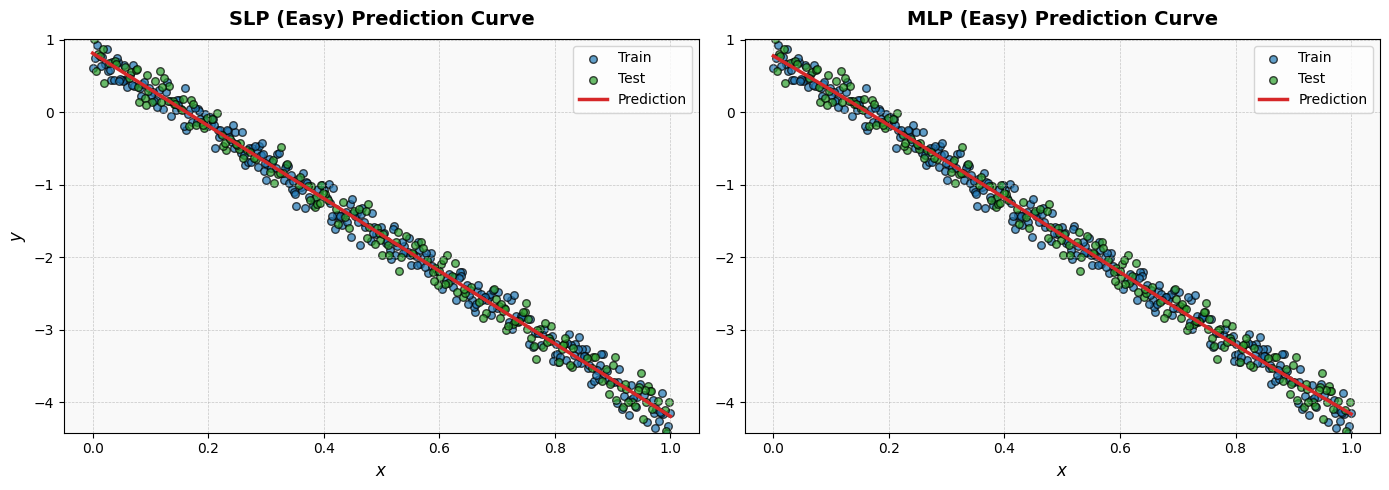

In [120]:
# Plot predictions for easy dataset
plot_side_by_side(
    model1=best_slp_easy,
    model2=best_mlp_easy,
    x_train=easy_x_train,
    y_train=easy_y,
    x_test=easy_x_test,
    y_test=easy_y_test,
    label1="SLP (Easy)",
    label2="MLP (Easy)"
)


In [ ]:
# Prepare medium dataset
medium_x_train = medium_x.reshape(-1, 1)
medium_x_test = np.loadtxt("data/medium_test.txt")[:, 0].reshape(-1, 1)
medium_y_test = np.loadtxt("data/medium_test.txt")[:, 1]

# Run grid search
best_slp_medium, slp_config_medium, slp_mse_medium = run_slp_grid(
    medium_x_train, medium_y, medium_x_test, medium_y_test
)

best_mlp_medium, mlp_config_medium, mlp_mse_medium = run_mlp_grid(
    medium_x_train, medium_y, medium_x_test, medium_y_test
)

# Log best models
print("\n✅ Best SLP on Medium:")
print(f"  MSE: {slp_mse_medium:.4f}")
print(f"  Config: lr={slp_config_medium[0]}, momentum={slp_config_medium[1]}")

print("\n✅ Best MLP on Medium:")
print(f"  MSE: {mlp_mse_medium:.4f}")
print(f"  Config: lr={mlp_config_medium[0]}, momentum={mlp_config_medium[1]}, "
      f"hidden={mlp_config_medium[2]}, activation={mlp_config_medium[3]}")


🔍 Evaluating SLP configurations...


<ipython-input-66-a81da73a32cb>:43: RuntimeWarning: invalid value encountered in subtract
  self.w -= self.lr * grad_w


❌ Failed config: lr=0.01, momentum=0.0, error=Input contains NaN.


<ipython-input-66-a81da73a32cb>:38: RuntimeWarning: invalid value encountered in add
  self.v_w = self.momentum * self.v_w + (1 - self.momentum) * grad_w


❌ Failed config: lr=0.01, momentum=0.5, error=Input contains NaN.


...

❌ Failed config: lr=1.0, momentum=0.5, hidden=8, act=tanh, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.5, hid=8, act=relu | Test MSE: 483.77443


<ipython-input-66-a81da73a32cb>:94: RuntimeWarning: invalid value encountered in multiply
  dz1 = da1 * self.act_deriv(z1)


❌ Failed config: lr=1.0, momentum=0.5, hidden=16, act=sigmoid, error=Input contains NaN.


<ipython-input-66-a81da73a32cb>:94: RuntimeWarning: invalid value encountered in multiply
  dz1 = da1 * self.act_deriv(z1)


❌ Failed config: lr=1.0, momentum=0.5, hidden=16, act=tanh, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.5, hid=16, act=relu | Test MSE: 551.96885
✅ MLP | lr=1.0, mom=0.9, hid=4, act=sigmoid | Test MSE: 448.61098
✅ MLP | lr=1.0, mom=0.9, hid=4, act=tanh | Test MSE: 466.89971
✅ MLP | lr=1.0, mom=0.9, hid=4, act=relu | Test MSE: 451.31584
✅ MLP | lr=1.0, mom=0.9, hid=8, act=sigmoid | Test MSE: 542.78229
✅ MLP | lr=1.0, mom=0.9, hid=8, act=tanh | Test MSE: 1171.14630
✅ MLP | lr=1.0, mom=0.9, hid=8, act=relu | Test MSE: 456.21626
✅ MLP | lr=1.0, mom=0.9, hid=16, act=sigmoid | Test MSE: 499.93285
✅ MLP | lr=1.0, mom=0.9, hid=16, act=tanh | Test MSE: 2270.05348
✅ MLP | lr=1.0, mom=0.9, hid=16, act=relu | Test MSE: 747.94914

✅ Best SLP on Medium:
  MSE: inf
  Config: lr=0.01, momentum=0.0

✅ Best MLP on Medium:
  MSE: 436.8902
  Config: lr=0.1, momentum=0.9, hidden=4, activation=relu


⚠️ Skipping Best SLP (Medium) plot: model did not converge.


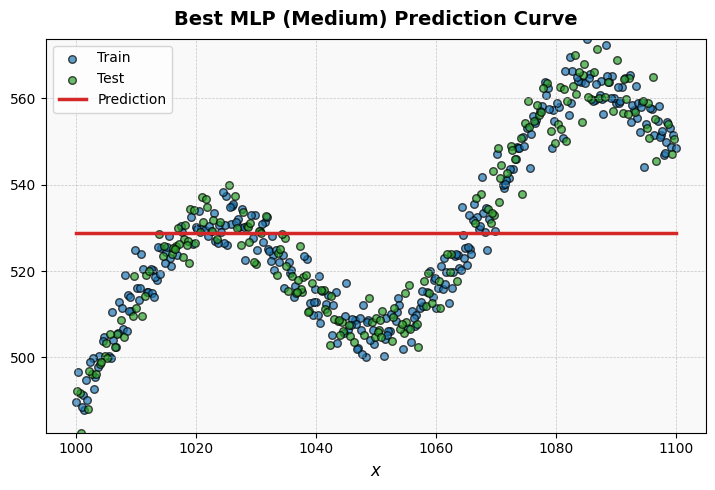

In [121]:
# Plot best SLP vs MLP on Medium Dataset
plot_side_by_side(
    model1=best_slp_medium,
    model2=best_mlp_medium,
    x_train=medium_x_train,
    y_train=medium_y,
    x_test=medium_x_test,
    y_test=medium_y_test,
    label1="Best SLP (Medium)",
    label2="Best MLP (Medium)"
)


In [ ]:
# Load Hard Dataset
hard_x, hard_y, hard_x_test, hard_y_test = load_dataset("data/hard_train.txt", "data/hard_test.txt")
hard_x_train = hard_x.reshape(-1, 1)
hard_x_test = hard_x_test.reshape(-1, 1)


# Run Grid Search on Hard Dataset
best_slp_hard, slp_config_hard, slp_mse_hard = run_slp_grid(
    hard_x_train, hard_y, hard_x_test, hard_y_test
)

best_mlp_hard, mlp_config_hard, mlp_mse_hard = run_mlp_grid(
    hard_x_train, hard_y, hard_x_test, hard_y_test
)


🔍 Evaluating SLP configurations...
✅ SLP | lr=0.01, momentum=0.0 | Test MSE: 1.65605
✅ SLP | lr=0.01, momentum=0.5 | Test MSE: 1.65683
✅ SLP | lr=0.01, momentum=0.9 | Test MSE: 1.65434
✅ SLP | lr=0.1, momentum=0.0 | Test MSE: 1.71422
✅ SLP | lr=0.1, momentum=0.5 | Test MSE: 1.69823
✅ SLP | lr=0.1, momentum=0.9 | Test MSE: 1.65244


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
<ipython-input-66-a81da73a32cb>:43: RuntimeWarning: invalid value encountered in subtract
  self.w -= self.lr * grad_w


❌ Failed config: lr=1.0, momentum=0.0, error=Input contains NaN.
✅ SLP | lr=1.0, momentum=0.5 | Test MSE: 12.18081
✅ SLP | lr=1.0, momentum=0.9 | Test MSE: 1.84105
🔍 Evaluating MLP configurations...
✅ MLP | lr=0.01, mom=0.0, hid=4, act=sigmoid | Test MSE: 1.62600
✅ MLP | lr=0.01, mom=0.0, hid=4, act=tanh | Test MSE: 1.64595
✅ MLP | lr=0.01, mom=0.0, hid=4, act=relu | Test MSE: 1.64209
✅ MLP | lr=0.01, mom=0.0, hid=8, act=sigmoid | Test MSE: 1.62539
✅ MLP | lr=0.01, mom=0.0, hid=8, act=tanh | Test MSE: 1.65880
✅ MLP | lr=0.01, mom=0.0, hid=8, act=relu | Test MSE: 1.64110
✅ MLP | lr=0.01, mom=0.0, hid=16, act=sigmoid | Test MSE: 1.62306
✅ MLP | lr=0.01, mom=0.0, hid=16, act=tanh | Test MSE: 1.65993
✅ MLP | lr=0.01, mom=0.0, hid=16, act=relu | Test MSE: 1.63271
✅ MLP | lr=0.01, mom=0.5, hid=4, act=sigmoid | Test MSE: 1.62926
✅ MLP | lr=0.01, mom=0.5, hid=4, act=tanh | Test MSE: 1.64727
✅ MLP | lr=0.01, mom=0.5, hid=4, act=relu | Test MSE: 1.66549
✅ MLP | lr=0.01, mom=0.5, hid=8, act=sigmo

<ipython-input-66-a81da73a32cb>:94: RuntimeWarning: invalid value encountered in multiply
  dz1 = da1 * self.act_deriv(z1)


❌ Failed config: lr=1.0, momentum=0.0, hidden=4, act=tanh, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.0, hid=4, act=relu | Test MSE: 19297.91632


...

❌ Failed config: lr=1.0, momentum=0.5, hidden=8, act=relu, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.5, hid=16, act=sigmoid | Test MSE: 1.62459


<ipython-input-66-a81da73a32cb>:94: RuntimeWarning: invalid value encountered in multiply
  dz1 = da1 * self.act_deriv(z1)


❌ Failed config: lr=1.0, momentum=0.5, hidden=16, act=tanh, error=Input contains NaN.


<ipython-input-66-a81da73a32cb>:82: RuntimeWarning: invalid value encountered in add
  z1 = np.dot(x_batch, self.W1) + self.b1


❌ Failed config: lr=1.0, momentum=0.5, hidden=16, act=relu, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.9, hid=4, act=sigmoid | Test MSE: 1.68355
✅ MLP | lr=1.0, mom=0.9, hid=4, act=tanh | Test MSE: 3.32430
✅ MLP | lr=1.0, mom=0.9, hid=4, act=relu | Test MSE: 1.89002
✅ MLP | lr=1.0, mom=0.9, hid=8, act=sigmoid | Test MSE: 2.03808
✅ MLP | lr=1.0, mom=0.9, hid=8, act=tanh | Test MSE: 5.02370
✅ MLP | lr=1.0, mom=0.9, hid=8, act=relu | Test MSE: 1.66487
✅ MLP | lr=1.0, mom=0.9, hid=16, act=sigmoid | Test MSE: 1.60704
✅ MLP | lr=1.0, mom=0.9, hid=16, act=tanh | Test MSE: 90.37994
✅ MLP | lr=1.0, mom=0.9, hid=16, act=relu | Test MSE: 1.68005


In [ ]:
# Report Results for Hard Dataset
print("\n✅ Best SLP on Hard:")
print(f"  MSE: {slp_mse_hard:.4f}")
print(f"  Config: lr={slp_config_hard[0]}, momentum={slp_config_hard[1]}")

print("\n✅ Best MLP on Hard:")
print(f"  MSE: {mlp_mse_hard:.4f}")
print(f"  Config: lr={mlp_config_hard[0]}, momentum={mlp_config_hard[1]}, "
      f"hidden={mlp_config_hard[2]}, activation={mlp_config_hard[3]}")



✅ Best SLP on Hard:
  MSE: 1.6524
  Config: lr=0.1, momentum=0.9

✅ Best MLP on Hard:
  MSE: 1.6043
  Config: lr=0.1, momentum=0.9, hidden=4, activation=tanh


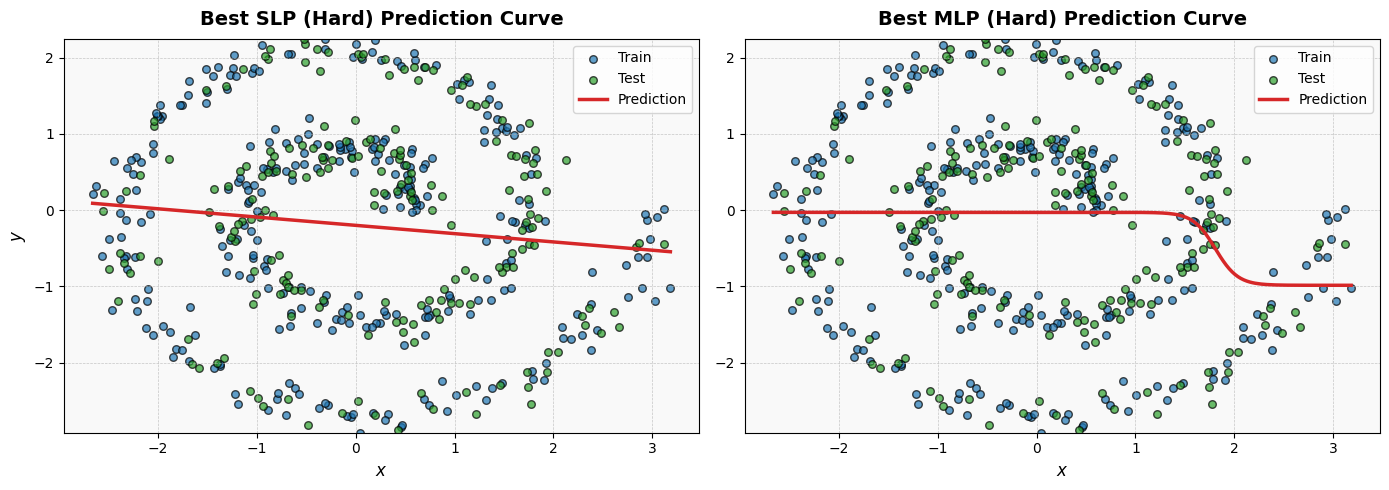

In [122]:
# Plot predictions of best SLP and MLP models for Hard Dataset
plot_side_by_side(
    model1=best_slp_hard,
    model2=best_mlp_hard,
    x_train=hard_x_train,
    y_train=hard_y,
    x_test=hard_x_test,
    y_test=hard_y_test,
    label1="Best SLP (Hard)",
    label2="Best MLP (Hard)"
)


# 4 Min-Max Scaling

In [ ]:
def load_dataset(train_path, test_path):
    train = np.loadtxt(train_path)
    test = np.loadtxt(test_path)
    x_train, y_train = train[:, 0], train[:, 1]
    x_test, y_test = test[:, 0], test[:, 1]
    return x_train, y_train, x_test, y_test

def min_max_scale(train, test):
    min_val, max_val = np.min(train), np.max(train)
    train_scaled = (train - min_val) / (max_val - min_val)
    test_scaled = (test - min_val) / (max_val - min_val)
    return train_scaled, test_scaled, min_val, max_val

# Load original medium dataset
medium_x, medium_y, medium_x_test, medium_y_test = load_dataset("data/medium_train.txt", "data/medium_test.txt")

# Normalize both x and y using min-max scaling based on training data
medium_x_scaled, medium_x_test_scaled, x_min, x_max = min_max_scale(medium_x, medium_x_test)
medium_y_scaled, medium_y_test_scaled, y_min, y_max = min_max_scale(medium_y, medium_y_test)

# Reshape input to (n_samples, 1)
medium_x_train_scaled = medium_x_scaled.reshape(-1, 1)
medium_x_test_scaled = medium_x_test_scaled.reshape(-1, 1)


In [ ]:
best_slp_scaled, slp_config_scaled, slp_mse_scaled = run_slp_grid(
    medium_x_train_scaled, medium_y_scaled,
    medium_x_test_scaled, medium_y_test_scaled
)

best_mlp_scaled, mlp_config_scaled, mlp_mse_scaled = run_mlp_grid(
    medium_x_train_scaled, medium_y_scaled,
    medium_x_test_scaled, medium_y_test_scaled
)




🔍 Evaluating SLP configurations...
✅ SLP | lr=0.01, momentum=0.0 | Test MSE: 0.02728
✅ SLP | lr=0.01, momentum=0.5 | Test MSE: 0.02731
✅ SLP | lr=0.01, momentum=0.9 | Test MSE: 0.02733
✅ SLP | lr=0.1, momentum=0.0 | Test MSE: 0.02819
✅ SLP | lr=0.1, momentum=0.5 | Test MSE: 0.02722
✅ SLP | lr=0.1, momentum=0.9 | Test MSE: 0.02729


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
<ipython-input-66-a81da73a32cb>:44: RuntimeWarning: invalid value encountered in scalar subtract
  self.b -= self.lr * grad_b


❌ Failed config: lr=1.0, momentum=0.0, error=Input contains NaN.
✅ SLP | lr=1.0, momentum=0.5 | Test MSE: 0.02863
✅ SLP | lr=1.0, momentum=0.9 | Test MSE: 0.03069
🔍 Evaluating MLP configurations...
✅ MLP | lr=0.01, mom=0.0, hid=4, act=sigmoid | Test MSE: 0.02756
✅ MLP | lr=0.01, mom=0.0, hid=4, act=tanh | Test MSE: 0.02735
✅ MLP | lr=0.01, mom=0.0, hid=4, act=relu | Test MSE: 0.02732
✅ MLP | lr=0.01, mom=0.0, hid=8, act=sigmoid | Test MSE: 0.02766
✅ MLP | lr=0.01, mom=0.0, hid=8, act=tanh | Test MSE: 0.02448
✅ MLP | lr=0.01, mom=0.0, hid=8, act=relu | Test MSE: 0.02719
✅ MLP | lr=0.01, mom=0.0, hid=16, act=sigmoid | Test MSE: 0.02763
✅ MLP | lr=0.01, mom=0.0, hid=16, act=tanh | Test MSE: 0.02282
✅ MLP | lr=0.01, mom=0.0, hid=16, act=relu | Test MSE: 0.02660
✅ MLP | lr=0.01, mom=0.5, hid=4, act=sigmoid | Test MSE: 0.02760
✅ MLP | lr=0.01, mom=0.5, hid=4, act=tanh | Test MSE: 0.02728
✅ MLP | lr=0.01, mom=0.5, hid=4, act=relu | Test MSE: 0.02730
✅ MLP | lr=0.01, mom=0.5, hid=8, act=sigmoi

<ipython-input-66-a81da73a32cb>:94: RuntimeWarning: invalid value encountered in multiply
  dz1 = da1 * self.act_deriv(z1)


❌ Failed config: lr=1.0, momentum=0.0, hidden=4, act=tanh, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.0, hid=4, act=relu | Test MSE: 256.36374
✅ MLP | lr=1.0, mom=0.0, hid=8, act=sigmoid | Test MSE: 3033.09927


...

❌ Failed config: lr=1.0, momentum=0.0, hidden=16, act=tanh, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.0, hid=16, act=relu | Test MSE: 5.25498
✅ MLP | lr=1.0, mom=0.5, hid=4, act=sigmoid | Test MSE: 0.01614
✅ MLP | lr=1.0, mom=0.5, hid=4, act=tanh | Test MSE: 0.00830
✅ MLP | lr=1.0, mom=0.5, hid=4, act=relu | Test MSE: 0.02162
✅ MLP | lr=1.0, mom=0.5, hid=8, act=sigmoid | Test MSE: 0.00515


<ipython-input-66-a81da73a32cb>:94: RuntimeWarning: invalid value encountered in multiply
  dz1 = da1 * self.act_deriv(z1)


❌ Failed config: lr=1.0, momentum=0.5, hidden=8, act=tanh, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.5, hid=8, act=relu | Test MSE: 0.06106
✅ MLP | lr=1.0, mom=0.5, hid=16, act=sigmoid | Test MSE: 0.02295


<ipython-input-66-a81da73a32cb>:94: RuntimeWarning: invalid value encountered in multiply
  dz1 = da1 * self.act_deriv(z1)


❌ Failed config: lr=1.0, momentum=0.5, hidden=16, act=tanh, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.5, hid=16, act=relu | Test MSE: 0.05976
✅ MLP | lr=1.0, mom=0.9, hid=4, act=sigmoid | Test MSE: 0.01558
✅ MLP | lr=1.0, mom=0.9, hid=4, act=tanh | Test MSE: 0.00299
✅ MLP | lr=1.0, mom=0.9, hid=4, act=relu | Test MSE: 0.01972
✅ MLP | lr=1.0, mom=0.9, hid=8, act=sigmoid | Test MSE: 0.00532
✅ MLP | lr=1.0, mom=0.9, hid=8, act=tanh | Test MSE: 0.00358
✅ MLP | lr=1.0, mom=0.9, hid=8, act=relu | Test MSE: 0.02000
✅ MLP | lr=1.0, mom=0.9, hid=16, act=sigmoid | Test MSE: 0.00288
✅ MLP | lr=1.0, mom=0.9, hid=16, act=tanh | Test MSE: 0.00290
✅ MLP | lr=1.0, mom=0.9, hid=16, act=relu | Test MSE: 0.01861


In [ ]:
print("\n✅ Best MLP on Medium (Min-Max Scaled):")
print(f"  MSE: {mlp_mse_scaled:.4f}")
print(f"  Config: lr={mlp_config_scaled[0]}, momentum={mlp_config_scaled[1]}, "
      f"hidden={mlp_config_scaled[2]}, activation={mlp_config_scaled[3]}")


print("\n✅ Best SLP on Medium (Min-Max Scaled):")
print(f"  MSE: {slp_mse_scaled:.4f}")
print(f"  Config: lr={slp_config_scaled[0]}, momentum={slp_config_scaled[1]}")


✅ Best MLP on Medium (Min-Max Scaled):
  MSE: 0.0029
  Config: lr=1.0, momentum=0.9, hidden=16, activation=sigmoid

✅ Best SLP on Medium (Min-Max Scaled):
  MSE: 0.0272
  Config: lr=0.1, momentum=0.5


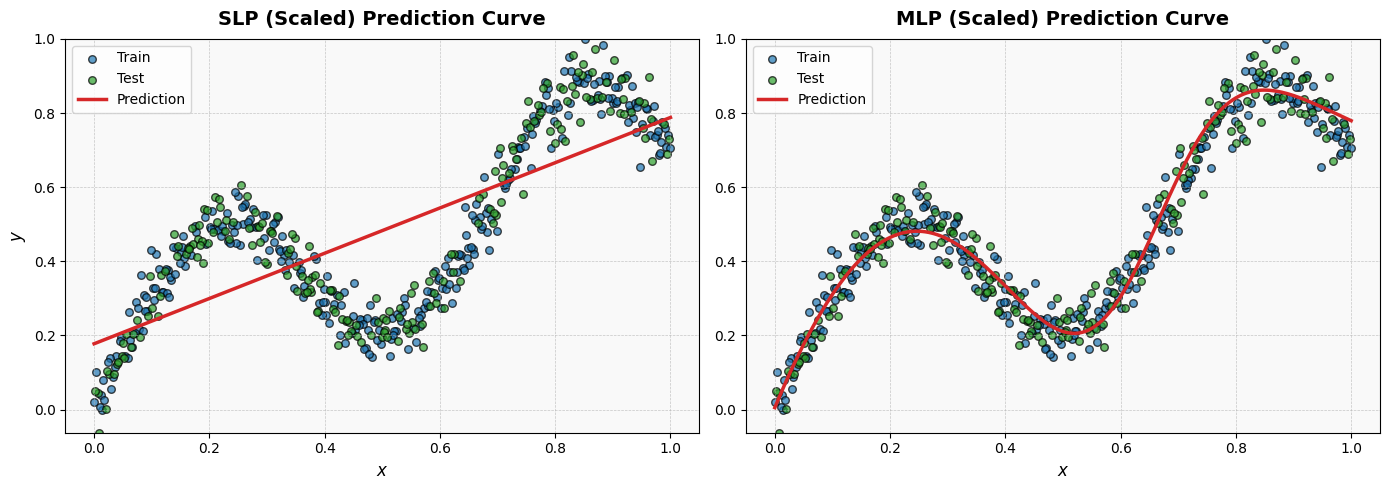

In [123]:
plot_side_by_side(
    model1=best_slp_scaled,
    model2=best_mlp_scaled,
    x_train=medium_x_train_scaled,
    y_train=medium_y_scaled,
    x_test=medium_x_test_scaled,
    y_test=medium_y_test_scaled,
    label1="SLP (Scaled)",
    label2="MLP (Scaled)"
)


# 5 Effect of Model Complexity

In [99]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

def min_max_scale(x, x_min, x_max):
    return (x - x_min) / (x_max - x_min)

def run_model_complexity_analysis(x_train, y_train, x_test, y_test, base_config, dataset_name, apply_scaling=False):
    lr, momentum, _, activation = base_config
    hidden_sizes = [2, 4, 8, 16]

    # Apply min-max scaling if specified
    if apply_scaling:
        x_min, x_max = x_train.min(), x_train.max()
        y_min, y_max = y_train.min(), y_train.max()

        x_train = min_max_scale(x_train, x_min, x_max)
        x_test = min_max_scale(x_test, x_min, x_max)
        y_train = min_max_scale(y_train, y_min, y_max)
        y_test = min_max_scale(y_test, y_min, y_max)

        x_dense = np.linspace(0, 1, 200).reshape(-1, 1)
    else:
        x_dense = np.linspace(min(x_train.min(), x_test.min()),
                              max(x_train.max(), x_test.max()), 200).reshape(-1, 1)

    # Store results for comparison
    test_mse_list = []
    models = []

    fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(20, 4), sharey=True)
    fig.suptitle(f"{dataset_name} Dataset: Effect of Hidden Layer Size", fontsize=16)

    for i, hidden_size in enumerate(hidden_sizes):
        model = MultiLayerPerceptron(
            input_dim=1,
            hidden_size=hidden_size,
            activation=activation,
            learning_rate=lr,
            momentum=momentum,
            weight_range=1.0
        )
        model.train(x_train, y_train, epochs=5000, batch_size=16, verbose=False)

        # Predictions
        y_pred_dense = model.predict(x_dense)
        y_pred_train = model.predict(x_train)
        y_pred_test = model.predict(x_test)

        train_mse = mean_squared_error(y_train, y_pred_train)
        test_mse = mean_squared_error(y_test, y_pred_test)

        test_mse_list.append(test_mse)
        models.append(model)

        # Plot
        axes[i].scatter(x_train, y_train, color='blue', alpha=0.6, label='Train')
        axes[i].scatter(x_test, y_test, color='green', alpha=0.6, label='Test')
        axes[i].plot(x_dense, y_pred_dense, color='red', linewidth=2, label='Prediction')
        axes[i].set_title(f"{hidden_size} Hidden\nTrain MSE: {train_mse:.4f}\nTest MSE: {test_mse:.4f}")
        axes[i].set_xlabel('$x$')
        if i == 0:
            axes[i].set_ylabel('$y$')
        axes[i].grid(True)
        axes[i].legend()

    # Highlight best model (lowest test MSE)
    best_idx = int(np.argmin(test_mse_list))
    axes[best_idx].set_title(
        f"★ {hidden_sizes[best_idx]} Hidden (Best)\nTrain MSE: {mean_squared_error(y_train, models[best_idx].predict(x_train)):.4f}\nTest MSE: {test_mse_list[best_idx]:.4f}",
        fontweight='bold', color='darkred'
    )
    for spine in axes[best_idx].spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(2)

    plt.tight_layout()
    plt.show()


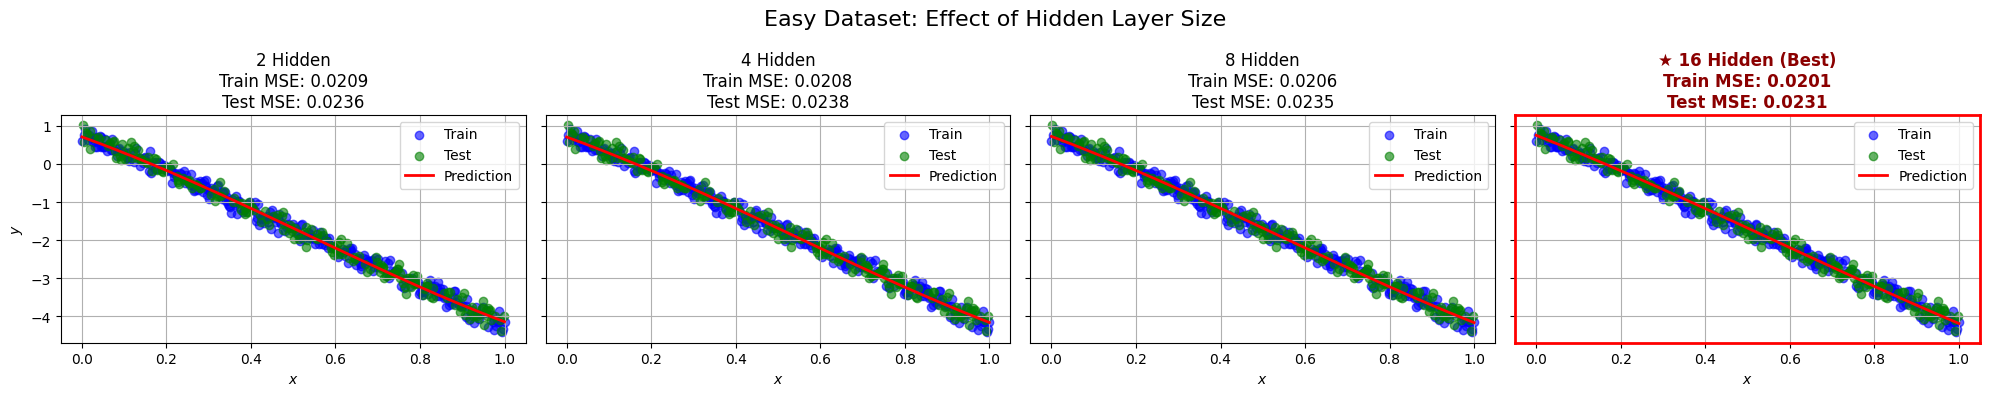

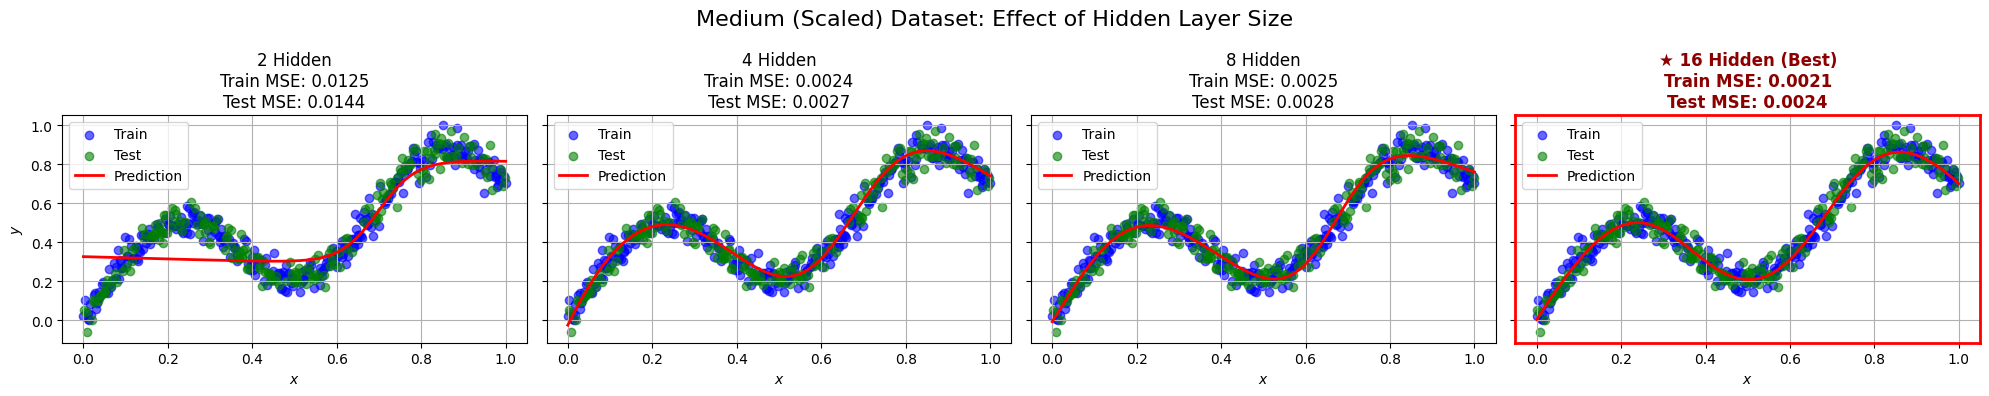

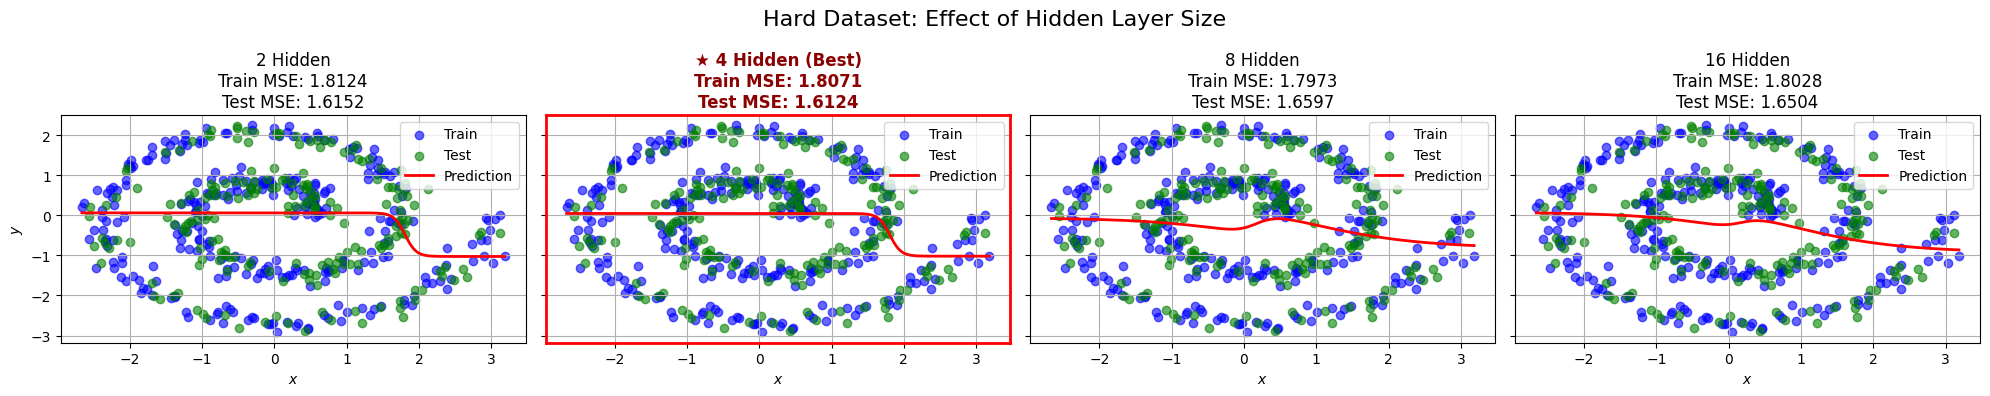

In [100]:
# Easy dataset
run_model_complexity_analysis(easy_x_train, easy_y, easy_x_test, easy_y_test, mlp_config_easy, "Easy")

# Medium dataset — with min-max scaling
run_model_complexity_analysis(medium_x_train, medium_y, medium_x_test, medium_y_test,
                              mlp_config_scaled, "Medium (Scaled)", apply_scaling=True)

# Hard dataset
run_model_complexity_analysis(hard_x_train, hard_y, hard_x_test, hard_y_test, mlp_config_hard, "Hard")
